In [5]:
import pandas as pd
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.neighbors import KNeighborsClassifier # type: ignore
from sklearn.model_selection import train_test_split # type: ignore
from sklearn.metrics import accuracy_score, confusion_matrix # type: ignore
from IPython.display import display # type: ignore

%matplotlib inline
sns.set_theme(style="whitegrid")


In [6]:
df = pd.read_csv('titanic.csv')
display(df.head())
# Удаляем неинформативные столбцы
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Заполняем пропуски в Embarked
df['Embarked'].fillna('S', inplace=True)

# Заполняем пропуски в возрасте по медиане класса
age_1 = df[df['Pclass'] == 1]['Age'].median()
age_2 = df[df['Pclass'] == 2]['Age'].median()
age_3 = df[df['Pclass'] == 3]['Age'].median()

def fill_age(row):
    if pd.isnull(row['Age']):
        if row['Pclass'] == 1:
            return age_1
        elif row['Pclass'] == 2:
            return age_2
        elif row['Pclass'] == 3:
            return age_3
    return row['Age']

df['Age'] = df.apply(fill_age, axis=1)

# Кодируем пол
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# Кодируем порт посадки
df = pd.concat([df, pd.get_dummies(df['Embarked'], prefix='Embarked')], axis=1)
df.drop('Embarked', axis=1, inplace=True)

# Признак "путешествует один"
df['Alone'] = ((df['SibSp'] + df['Parch']) == 0).astype(int)

display(df.head())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Alone
0,0,3,1,22.0,1,0,7.2500,False,False,True,0
1,1,1,0,38.0,1,0,71.2833,True,False,False,0
2,1,3,0,26.0,0,0,7.9250,False,False,True,1
3,1,1,0,35.0,1,0,53.1000,False,False,True,0
4,0,3,1,35.0,0,0,8.0500,False,False,True,1


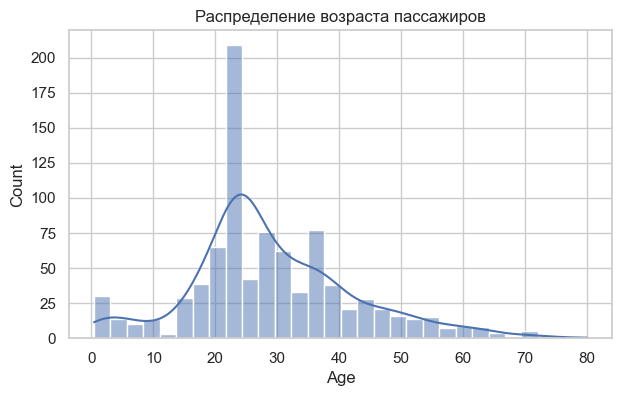

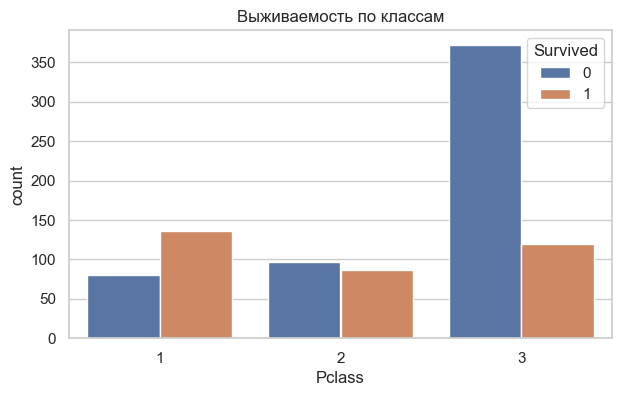

In [7]:
plt.figure(figsize=(7,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Распределение возраста пассажиров')
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Выживаемость по классам')
plt.show()


Точность: 81.17%


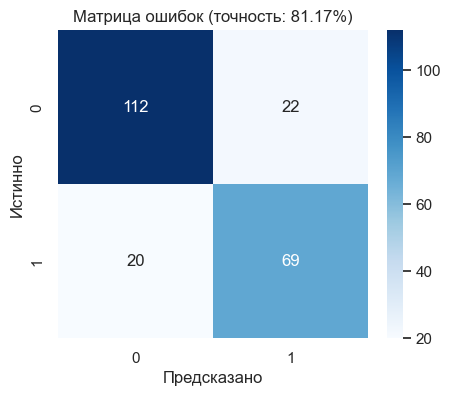

In [8]:
x = df.drop('Survived', axis=1)
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(x_train, y_train)

y_pred = classifier.predict(x_test)

accuracy = accuracy_score(y_test, y_pred) * 100
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Точность: {accuracy:.2f}%")

plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Матрица ошибок (точность: {accuracy:.2f}%)')
plt.xlabel('Предсказано')
plt.ylabel('Истинно')
plt.show()


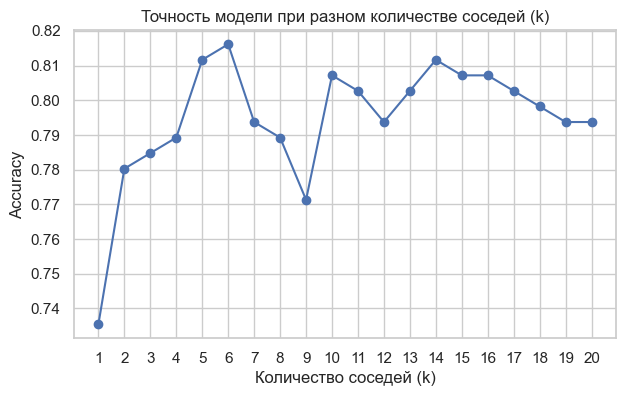

In [11]:
scores = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)

plt.figure(figsize=(7,4))
plt.plot(range(1, 21), scores, marker='o')
plt.title('Точность модели при разном количестве соседей (k)')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.show()
